# Bike Sharing Demand Prediction — Data Cleaning & Feature Engineering

## 1. Imports & Load Raw Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings; warnings.filterwarnings('ignore')
from utils import load_data, preprocess_data, create_features
sns.set_style('whitegrid')
pd.set_option('display.max_columns', None)
%matplotlib inline

In [2]:
df = load_data()
print('Raw shape:', df.shape)
df.head()

Raw shape: (17379, 13)


,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,cnt
0,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,16
1,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,40
2,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,32
3,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,13
4,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,1


## 2. Handle Missing / Invalid Values

In [3]:
print('Missing values:', df.isnull().sum().sum())
print('Duplicates:', df.duplicated().sum())
df_clean = df.copy()

Missing values: 0
Duplicates: 2


## 3. Imputation

In [4]:
df_imputed = df_clean.copy()
print('NaN count:', df_imputed.isnull().sum().sum())

NaN count: 0


## 4. Distribution Comparison Before vs After Imputation

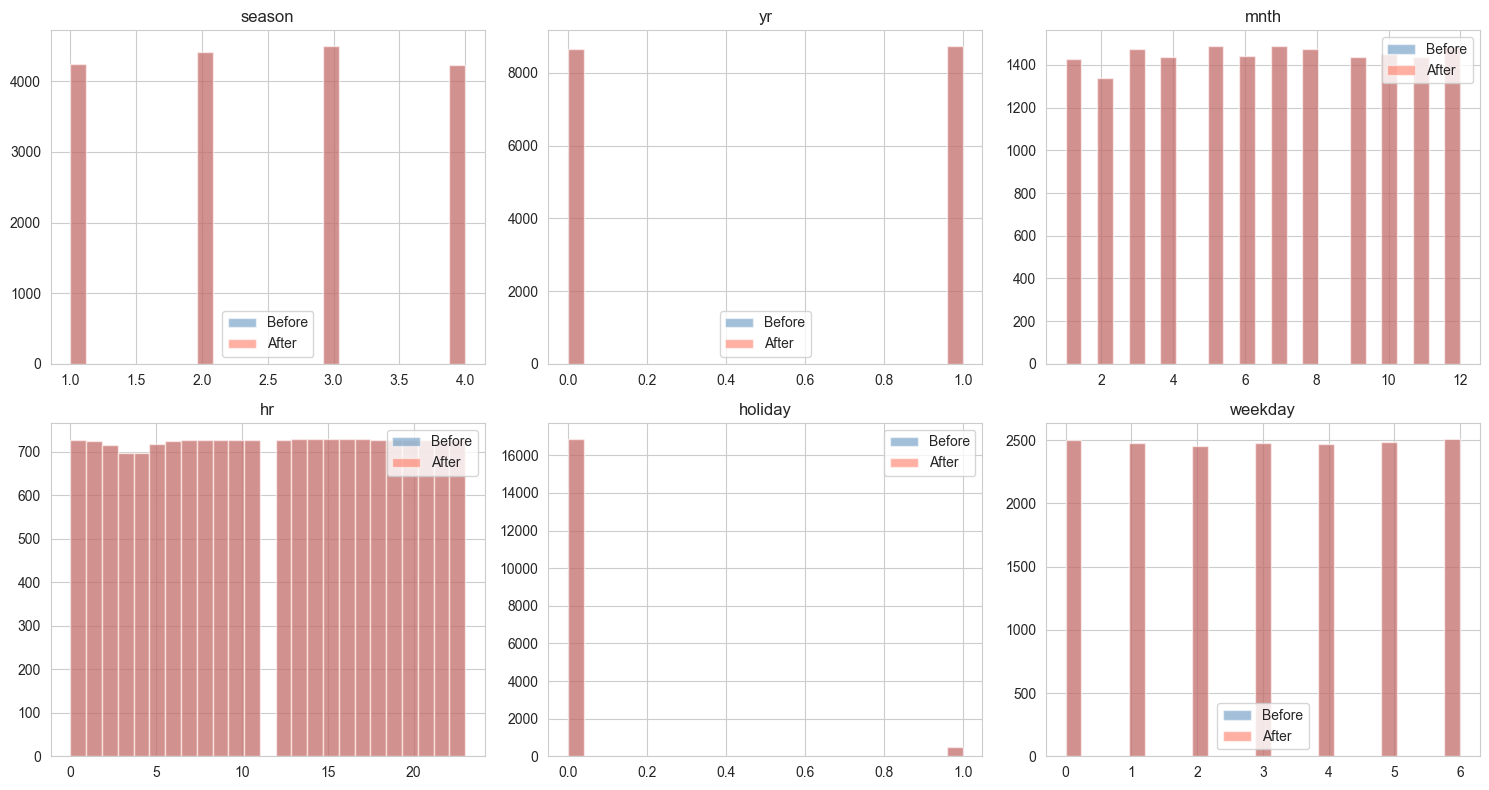

In [5]:
numeric_cols_for_plot = df.select_dtypes(include=[np.number]).columns[:6].tolist()
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
for i, col in enumerate(numeric_cols_for_plot):
    if i >= 6: break
    if col in df.columns:
        axes[i].hist(df[col].dropna(), bins=25, alpha=0.5, label='Before', color='steelblue')
    if col in df_imputed.columns:
        axes[i].hist(df_imputed[col], bins=25, alpha=0.5, label='After', color='tomato')
    axes[i].set_title(col); axes[i].legend()
plt.tight_layout(); plt.show()

## 5. Feature Engineering

In [6]:
df_feat = create_features(df_imputed)
print('After feature engineering:', df_feat.shape)
df_feat.head()

After feature engineering: (17379, 21)


,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,cnt,hr_sin,hr_cos,IsRushHour,IsNight,mnth_sin,mnth_cos,IsWeekend,ComfortIndex
0,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,16,0.000000,1.000000,0,1,0.5,0.866025,1,-0.165
1,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,40,0.258819,0.965926,0,1,0.5,0.866025,1,-0.180
2,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,32,0.500000,0.866025,0,1,0.5,0.866025,1,-0.180
3,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,13,0.707107,0.707107,0,1,0.5,0.866025,1,-0.135
4,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,1,0.866025,0.500000,0,1,0.5,0.866025,1,-0.135


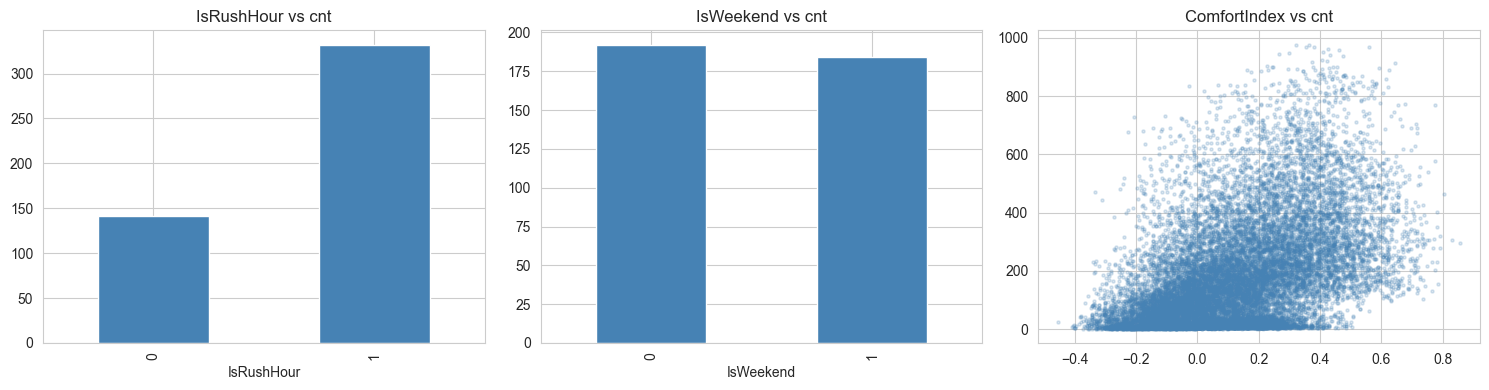

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ['IsRushHour', 'IsWeekend', 'ComfortIndex']):
    if col in df_feat.columns:
        if df_feat[col].nunique() == 2:
            df_feat.groupby(col)['cnt'].mean().plot(kind='bar', ax=ax, color='steelblue')
        else:
            ax.scatter(df_feat[col], df_feat['cnt'], alpha=0.2, s=5, color='steelblue')
        ax.set_title(f'{col} vs cnt')
plt.tight_layout(); plt.show()

## 6. Encode Categorical Features

In [8]:
cat_cols = df_feat.select_dtypes(include=['object', 'category']).columns.tolist()
print('Categorical columns:', cat_cols)
df_encoded = pd.get_dummies(df_feat, columns=cat_cols, drop_first=True)
bool_cols = df_encoded.select_dtypes(include=['bool']).columns
df_encoded[bool_cols] = df_encoded[bool_cols].astype(int)
print('Final shape:', df_encoded.shape)

Categorical columns: []
Final shape: (17379, 21)


## 7. Verify & Save Cleaned Dataset

In [9]:
print('Missing values:', df_encoded.isnull().sum().sum())
print('Final shape:', df_encoded.shape)
df_encoded.to_csv('data/bike_sharing_cleaned.csv', index=False)
print('Saved -> data/bike_sharing_cleaned.csv')
df_encoded.head()

Missing values: 0
Final shape: (17379, 21)


Saved -> data/bike_sharing_cleaned.csv


,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,cnt,hr_sin,hr_cos,IsRushHour,IsNight,mnth_sin,mnth_cos,IsWeekend,ComfortIndex
0,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,16,0.000000,1.000000,0,1,0.5,0.866025,1,-0.165
1,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,40,0.258819,0.965926,0,1,0.5,0.866025,1,-0.180
2,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,32,0.500000,0.866025,0,1,0.5,0.866025,1,-0.180
3,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,13,0.707107,0.707107,0,1,0.5,0.866025,1,-0.135
4,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,1,0.866025,0.500000,0,1,0.5,0.866025,1,-0.135
